<a href="https://colab.research.google.com/github/Keshav-kaushik22/-keshav-kaushik/blob/main/yt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score




In [2]:
data = pd.read_csv("/content/youtube_channel_real_performance_analytics (2).csv")
print(data.info)

<bound method DataFrame.info of       ID  Video Duration   Video Publish Time  Days Since Publish  Day  Month  \
0      0           201.0  2016-06-02 00:00:00                   0    2      6   
1      1           391.0  2016-06-10 00:00:00                   8   10      6   
2      2           133.0  2016-06-14 00:00:00                   4   14      6   
3      3            14.0  2016-06-29 00:00:00                  15   29      6   
4      4            45.0  2016-07-01 00:00:00                   2    1      7   
..   ...             ...                  ...                 ...  ...    ...   
359  359           779.0  2024-08-25 00:00:00                  10   25      8   
360  360           818.0  2024-09-01 00:00:00                   7    1      9   
361  361          2233.0  2024-09-16 00:00:00                  15   16      9   
362  362           391.0  2024-09-25 00:00:00                   9   25      9   
363  363          1875.0  2024-10-18 00:00:00                  23   18     10

In [3]:
print(data.isnull().sum())

ID                         0
Video Duration             0
Video Publish Time         0
Days Since Publish         0
Day                        0
                          ..
Watch Time (hours)         0
Subscribers                0
Estimated Revenue (USD)    0
Impressions                0
Video Thumbnail CTR (%)    0
Length: 70, dtype: int64


In [5]:
data.head()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [6]:
#Data cleaning
data = data.dropna()

In [11]:
print(data['Video Duration'].head())



0    201.0
1    391.0
2    133.0
3     14.0
4     45.0
Name: Video Duration, dtype: float64


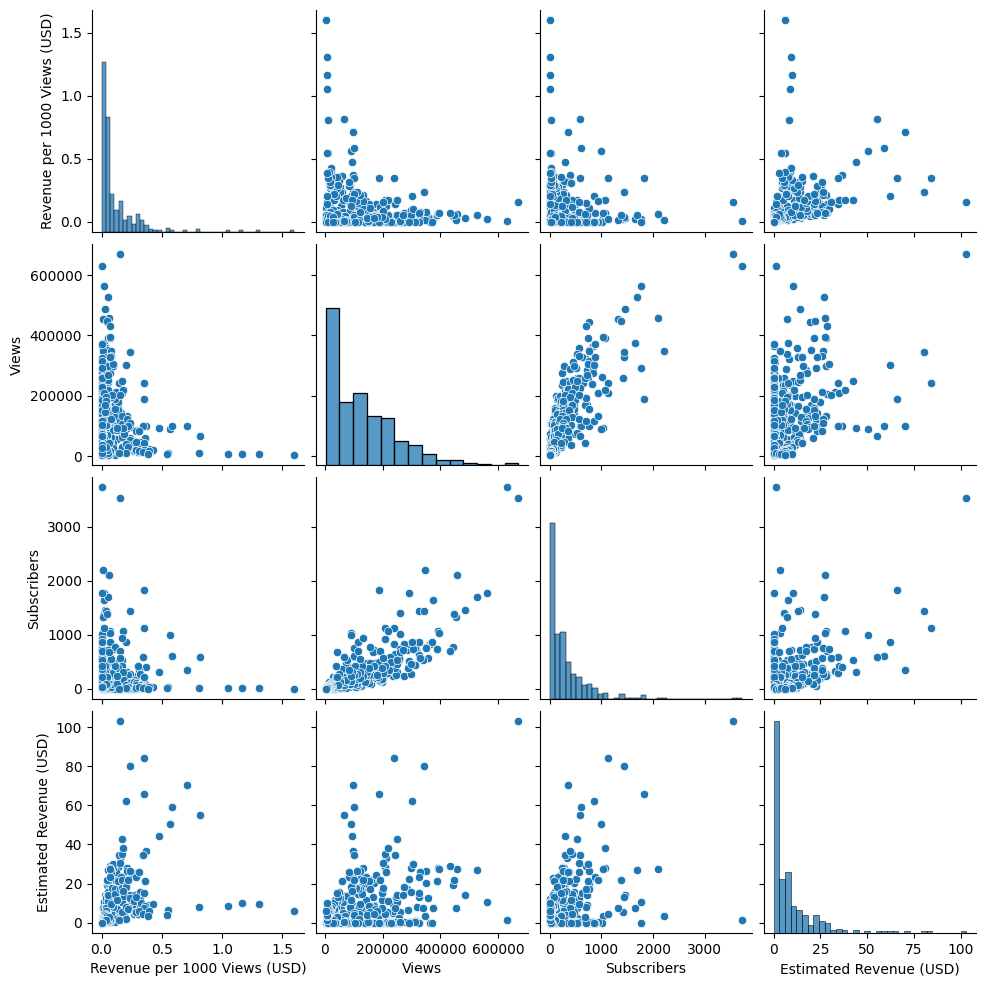

In [12]:
sns.pairplot(data[['Revenue per 1000 Views (USD)', 'Views',
'Subscribers', 'Estimated Revenue (USD)']])
plt.show()

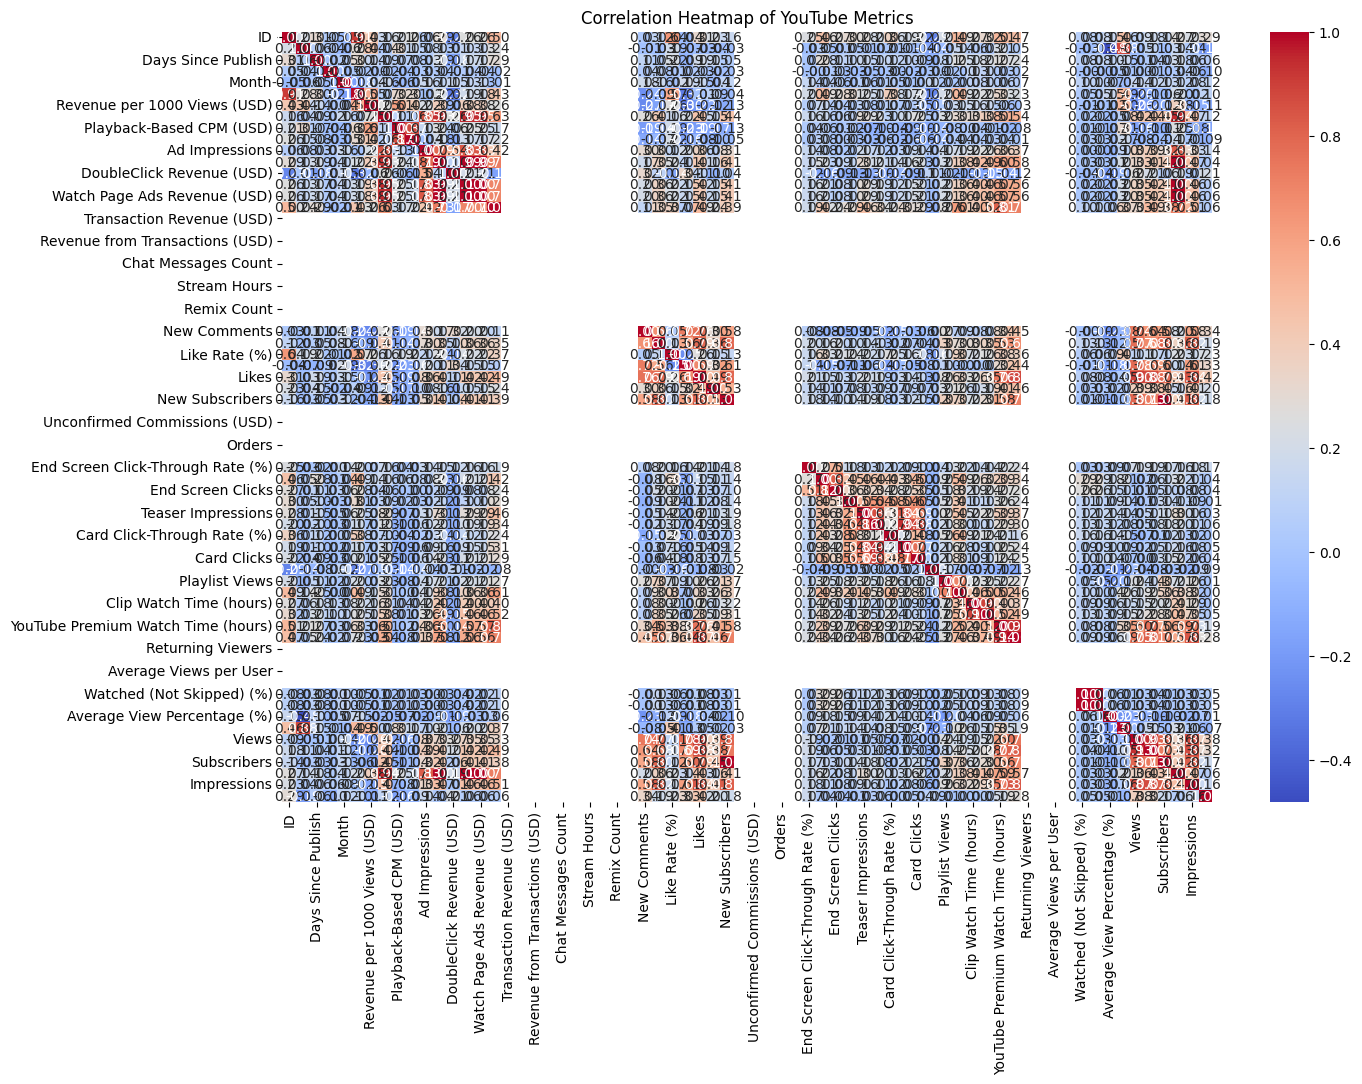

In [14]:
plt.figure(figsize=(15, 10))

numeric_df = data.select_dtypes(include=['float64', 'int64'])


sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap of YouTube Metrics")
plt.show()


In [15]:
top_videos = data.sort_values(by='Estimated Revenue (USD)',
ascending=False).head(10)
print(top_videos[['ID', 'Estimated Revenue (USD)', 'Views',
'Subscribers']])

      ID  Estimated Revenue (USD)     Views  Subscribers
228  228                  103.117  670990.0       3538.0
257  257                   83.979  241060.0       1125.0
251  251                   80.265  343319.0       1437.0
289  289                   70.247   99196.0        350.0
278  278                   65.978  188324.0       1824.0
260  260                   62.047  302999.0        866.0
293  293                   59.058  101025.0        602.0
294  294                   55.040   67556.0        581.0
290  290                   50.344   89284.0        995.0
284  284                   44.228   93487.0        305.0


In [18]:
print(data.columns.tolist())



['ID', 'Video Duration', 'Video Publish Time', 'Days Since Publish', 'Day', 'Month', 'Year', 'Day of Week', 'Revenue per 1000 Views (USD)', 'Monetized Playbacks (Estimate)', 'Playback-Based CPM (USD)', 'CPM (USD)', 'Ad Impressions', 'Estimated AdSense Revenue (USD)', 'DoubleClick Revenue (USD)', 'YouTube Ads Revenue (USD)', 'Watch Page Ads Revenue (USD)', 'YouTube\xa0Premium (USD)', 'Transaction Revenue (USD)', 'Transactions', 'Revenue from Transactions (USD)', 'Reactions', 'Chat Messages Count', 'Reminders Set', 'Stream Hours', 'Remix Views', 'Remix Count', 'Subscribers from Posts', 'New Comments', 'Shares', 'Like Rate (%)', 'Dislikes', 'Likes', 'Unsubscribes', 'New Subscribers', 'Returned Items (USD)', 'Unconfirmed Commissions (USD)', 'Approved Commissions (USD)', 'Orders', 'Total Sales Volume (USD)', 'End Screen Click-Through Rate (%)', 'End Screen Impressions', 'End Screen Clicks', 'Teaser Click-Through Rate (%)', 'Teaser Impressions', 'Teaser Clicks', 'Card Click-Through Rate (%)'

In [19]:
# Create revenue per view
data['Revenue per View'] = data['Estimated Revenue (USD)'] / data['Views']
# Create engagement rate
# Inspecting the columns, it seems 'Comments' is not present. Let's check for similar column names.
# Upon inspection of the dataset, it seems 'New Comments' is the correct column name.
data['Engagement Rate'] = (data['Likes'] + data['Shares'] + data['New Comments']) / data['Views'] * 100

In [39]:
features = [
    Likes, Dislikes, Shares, Subscribers, New Comments, Unsubscribes
]

target = 'Views'

X = data[features]
y = data[target]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (ipython-input-197873483.py, line 2)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)

In [32]:
model = RandomForestRegressor(n_estimators=300,max_depth=20,
random_state=42)
model.fit(X_train, y_train)
# Predict on test data
y_pred = model.predict(X_test)

In [35]:

r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

R-squared: 0.90


In [37]:
import pandas as pd
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)


Likes                          0.408581
Dislikes                       0.291556
Shares                         0.115847
New Subscribers                0.103712
New Comments                   0.029833
Unsubscribes                   0.019198
Like Rate (%)                  0.011697
Average View Percentage (%)    0.009806
Average View Duration          0.009710
Watched (Not Skipped) (%)      0.000032
Feed Impressions               0.000028
Subscribers from Posts         0.000000
Unique Viewers                 0.000000
Average Views per User         0.000000
New Viewers                    0.000000
Returning Viewers              0.000000
dtype: float64
